# Full BNS + NSBH likelihood

This notebook runs the six-parameter joint likelihood directly. It does **not** load a BNS-only backend or use a KDE posterior as a prior. For each run, $f_j^{\rm BNS}$, the geometry-efficiency function, $\alpha_{\rm CE}$, and the NSBH population are fixed; the spectral parameters and both opening angles are sampled.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib                import Path
import matplotlib.pyplot    as plt
#plt.style.use('../../../configurations/style.mplstyle')
from montecarlo_combined import run_pop
from maggpy.top_hat.geometric_eff import (
    geometric_efficiency_flat_midpoint, 
    geometric_efficiency_fixed, 
    create_geometric_efficiency_lognormal_interpolator
)
interp_ln = create_geometric_efficiency_lognormal_interpolator()
def geometric_efficiency_lognormal(theta): return interp_ln(theta)

## Run configuration

Edit `FJ_LIST` and `NSBH_POPULATIONS` before launching the chains. Every combination gets its own resumable `emcee.h5` backend.

In [ ]:
DATAFILES       = Path('../../datafiles')
IMAGES_FOLDER   = Path('Images')
IMAGES_FOLDER.mkdir(parents=True, exist_ok=True)

POSSIBLE_ALPHA  = ['A3.0', 'A5.0']
FJ_LIST         = [0.1, 0.5, 1.0]
POPULATION      = "qcbse"
NSBH_SERIES     = [
    'NSBH_DD2_uniform_chi_0_1',
    'NSBH_SFHo_uniform_chi_0_1',
]
SERIES_LABELS = [
    r"DD2, $\chi \sim \mathcal{U}(0,1)$",
    r"SFHo, $\chi \sim \mathcal{U}(0,1)$",
]
MRD_FOLDER = DATAFILES / "MRD_outputs"
MRD_BNS = [
    "qcbse_A3_0_BNS.csv",
    "qcbse_A5_0_BNS.csv"
]
MRD_NSBH = [
    "qcbse_A3_0_NSBH_DD2_uniform_chi_0_1.csv",
    "qcbse_A3_0_NSBH_SFHo_uniform_chi_0_1.csv",
    "qcbse_A5_0_NSBH_DD2_uniform_chi_0_1.csv",
    "qcbse_A5_0_NSBH_SFHo_uniform_chi_0_1.csv",
]

#GEOM_EFF_FUNC   = geometric_efficiency_fixed #geometric_efficiency_lognormal #geometric_efficiency_flat_midpoint
GEOM_EFF_FUNC = geometric_efficiency_flat_midpoint
GEOM_NAME       = GEOM_EFF_FUNC.__name__
GEOM_LABEL_DIC = {
    "geometric_efficiency_flat_midpoint"    : "midpoint",
    "geometric_efficiency_fixed"            : "fixed",
    "geometric_efficiency_lognormal"        : "lognormal",
}
GEOM_LABEL_CURRENT  = GEOM_LABEL_DIC[GEOM_NAME]
N_STEPS             = 1_000

print(f"Current geometric efficiency function: {GEOM_NAME} ({GEOM_LABEL_CURRENT})")

Current geometric efficiency function: geometric_efficiency_flat_midpoint (midpoint)


In [8]:
required_mrd_files = set()

for alpha in POSSIBLE_ALPHA:
    alpha_file = alpha.replace(".", "_")

    required_mrd_files.add(
        MRD_FOLDER / f"{POPULATION}_{alpha_file}_BNS.csv"
    )

    for nsbh_series in NSBH_SERIES:
        required_mrd_files.add(
            MRD_FOLDER / f"{POPULATION}_{alpha_file}_{nsbh_series}.csv"
        )

missing_mrd_files = [
    path for path in sorted(required_mrd_files)
    if not path.is_file()
]

if missing_mrd_files:
    # list all csv files in the MRD folder
    print(f"MRD folder contents: {sorted(MRD_FOLDER.glob('*.csv'))}")
    raise FileNotFoundError(
        "The following MRD files are missing:\n"
        + "\n".join(str(path) for path in missing_mrd_files)
    )

print(f"Found all {len(required_mrd_files)} required MRD files.")

Found all 6 required MRD files.


## Run or resume all chains

The initial walkers are generated inside the flat-prior support; no previous chain is read. Re-running this cell resumes matching backends up to `N_STEPS`.

In [ ]:
from itertools import product
samplers = {}

for alpha, fj_bsn, nsbh_series in product(POSSIBLE_ALPHA, FJ_LIST, NSBH_SERIES):
    mrd_bns_path    = MRD_FOLDER / f"{POPULATION}_{alpha.replace('.', '_')}_BNS.csv"
    mrd_nsbh_path   = MRD_FOLDER / f"{POPULATION}_{alpha.replace('.', '_')}_{nsbh_series}.csv"

    sampler = run_pop(
        mrd_bns_path     = mrd_bns_path,
        mrd_nsbh_path    = mrd_nsbh_path,
        fj_bns           = fj_bsn,
        geom_eff_func    = GEOM_EFF_FUNC,
        datafiles        = DATAFILES,
        n_steps          = N_STEPS,
    )

    samplers[(fj_bsn, alpha, nsbh_series)] = sampler

Running for alpha=A3.0, fj_bsn=0.1, nsbh_series=NSBH_DD2_uniform_chi_0_1
True True
Running for alpha=A3.0, fj_bsn=0.1, nsbh_series=NSBH_SFHo_uniform_chi_0_1
True True
Running for alpha=A3.0, fj_bsn=0.5, nsbh_series=NSBH_DD2_uniform_chi_0_1
True True
Running for alpha=A3.0, fj_bsn=0.5, nsbh_series=NSBH_SFHo_uniform_chi_0_1
True True
Running for alpha=A3.0, fj_bsn=1.0, nsbh_series=NSBH_DD2_uniform_chi_0_1
True True
Running for alpha=A3.0, fj_bsn=1.0, nsbh_series=NSBH_SFHo_uniform_chi_0_1
True True
Running for alpha=A5.0, fj_bsn=0.1, nsbh_series=NSBH_DD2_uniform_chi_0_1
True True
Running for alpha=A5.0, fj_bsn=0.1, nsbh_series=NSBH_SFHo_uniform_chi_0_1
True True
Running for alpha=A5.0, fj_bsn=0.5, nsbh_series=NSBH_DD2_uniform_chi_0_1
True True
Running for alpha=A5.0, fj_bsn=0.5, nsbh_series=NSBH_SFHo_uniform_chi_0_1
True True
Running for alpha=A5.0, fj_bsn=1.0, nsbh_series=NSBH_DD2_uniform_chi_0_1
True True
Running for alpha=A5.0, fj_bsn=1.0, nsbh_series=NSBH_SFHo_uniform_chi_0_1
True Tru

## Six-parameter corner plots

Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.1_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.1_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A5.0_fj_0.1_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A5.0_fj_0.1_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1


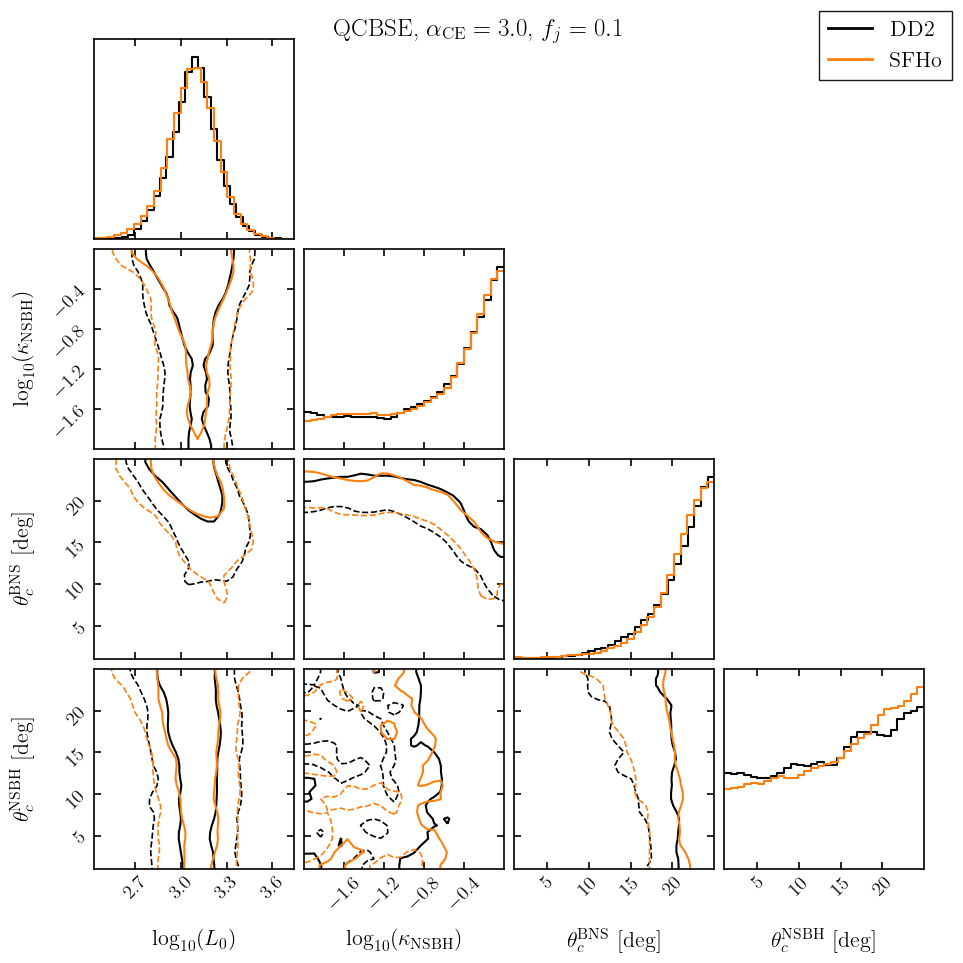

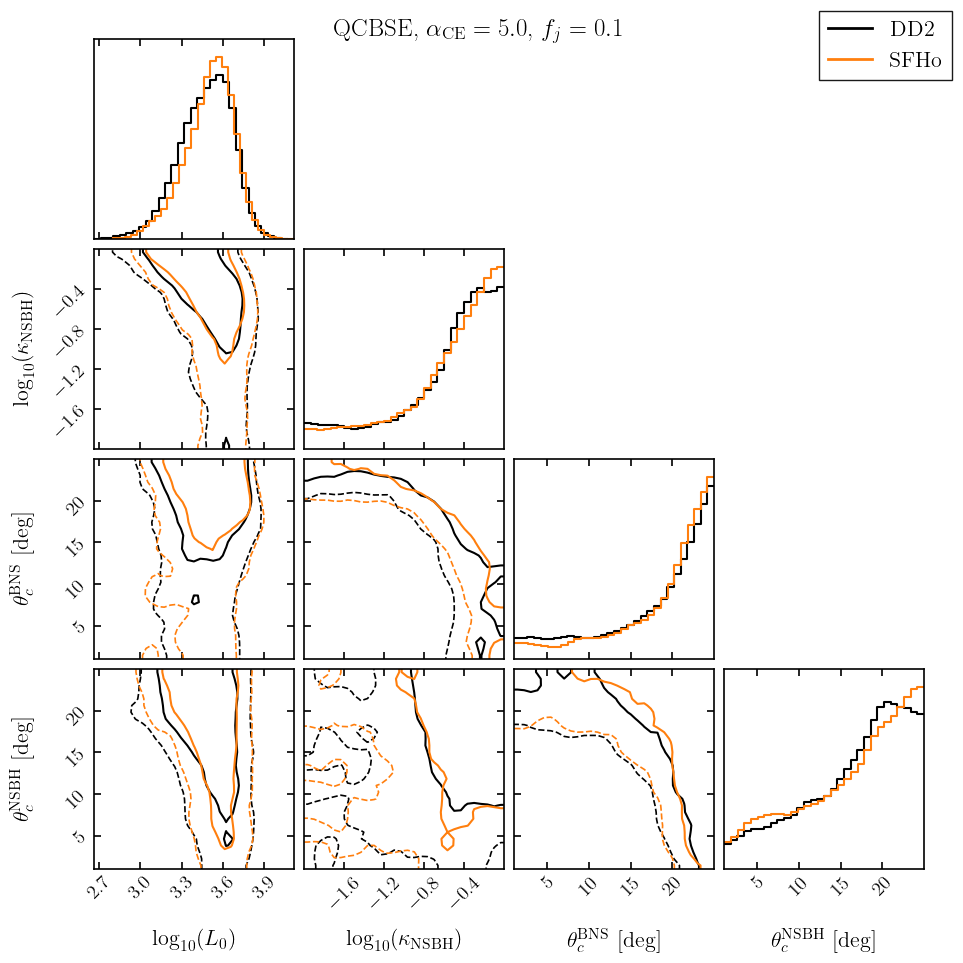

Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.5_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.5_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A5.0_fj_0.5_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A5.0_fj_0.5_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1


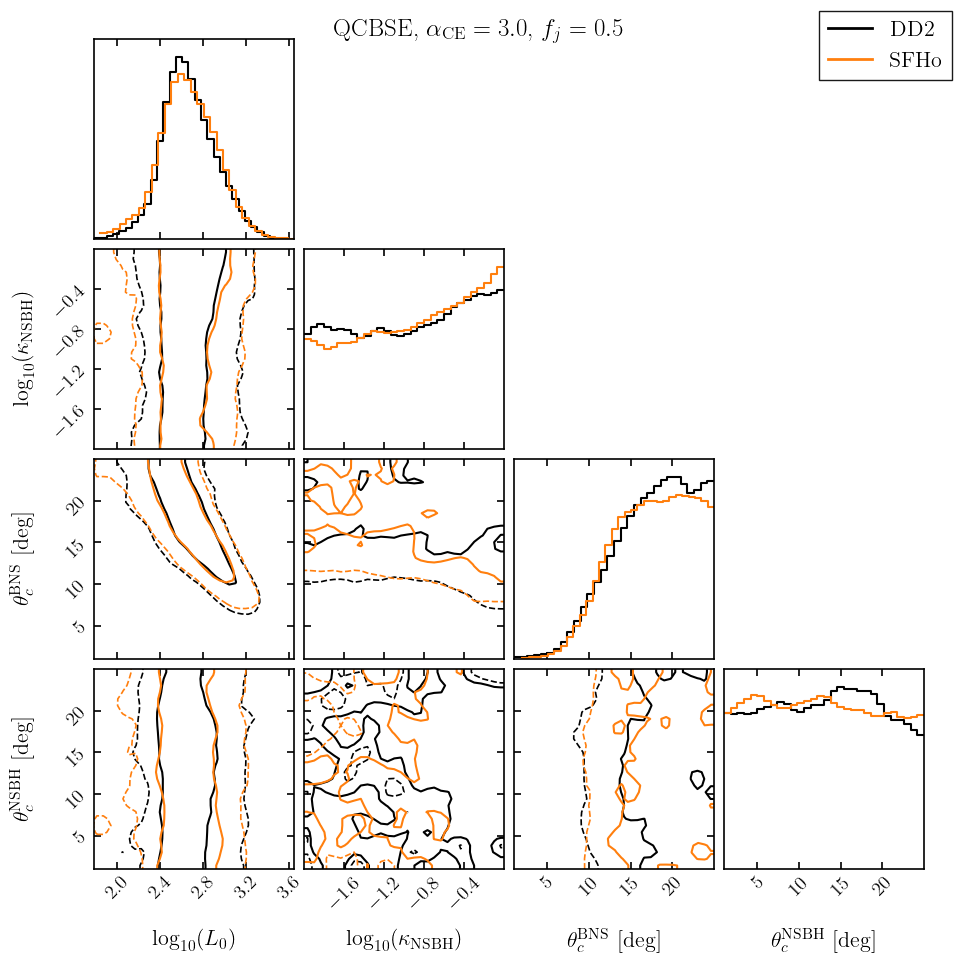

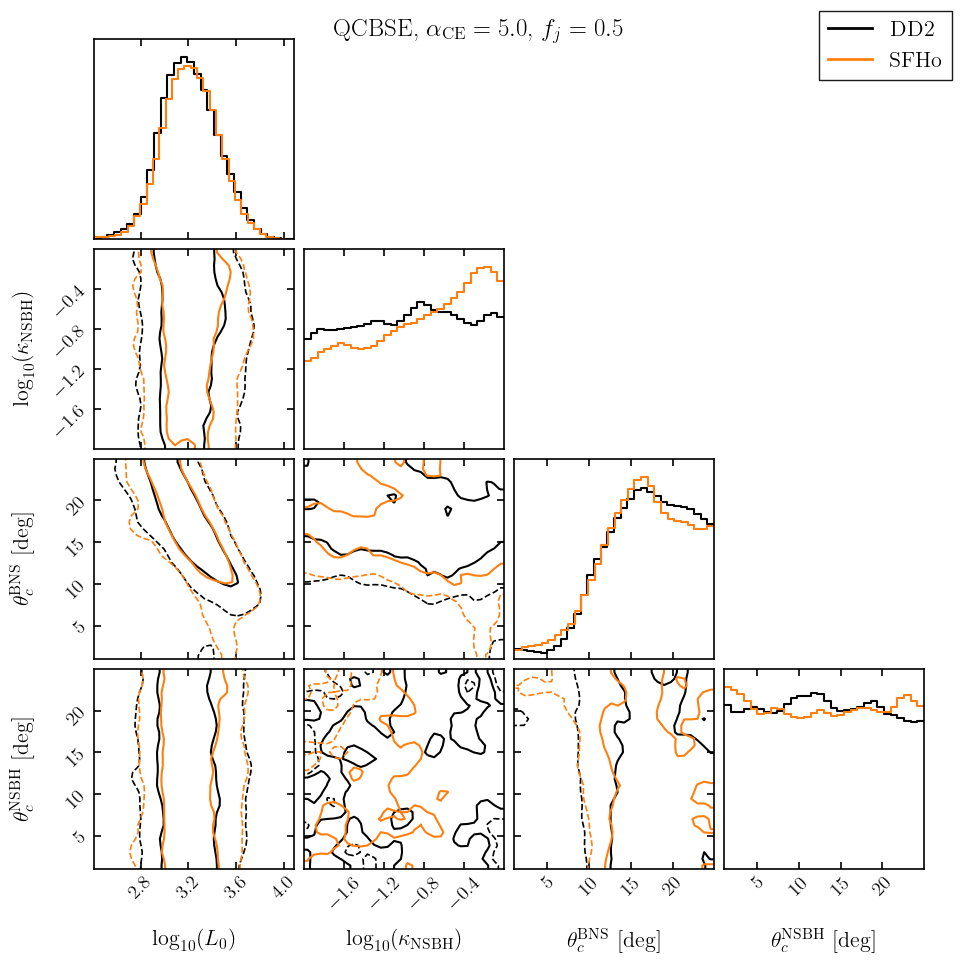

Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_1_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_1_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A5.0_fj_1_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A5.0_fj_1_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1


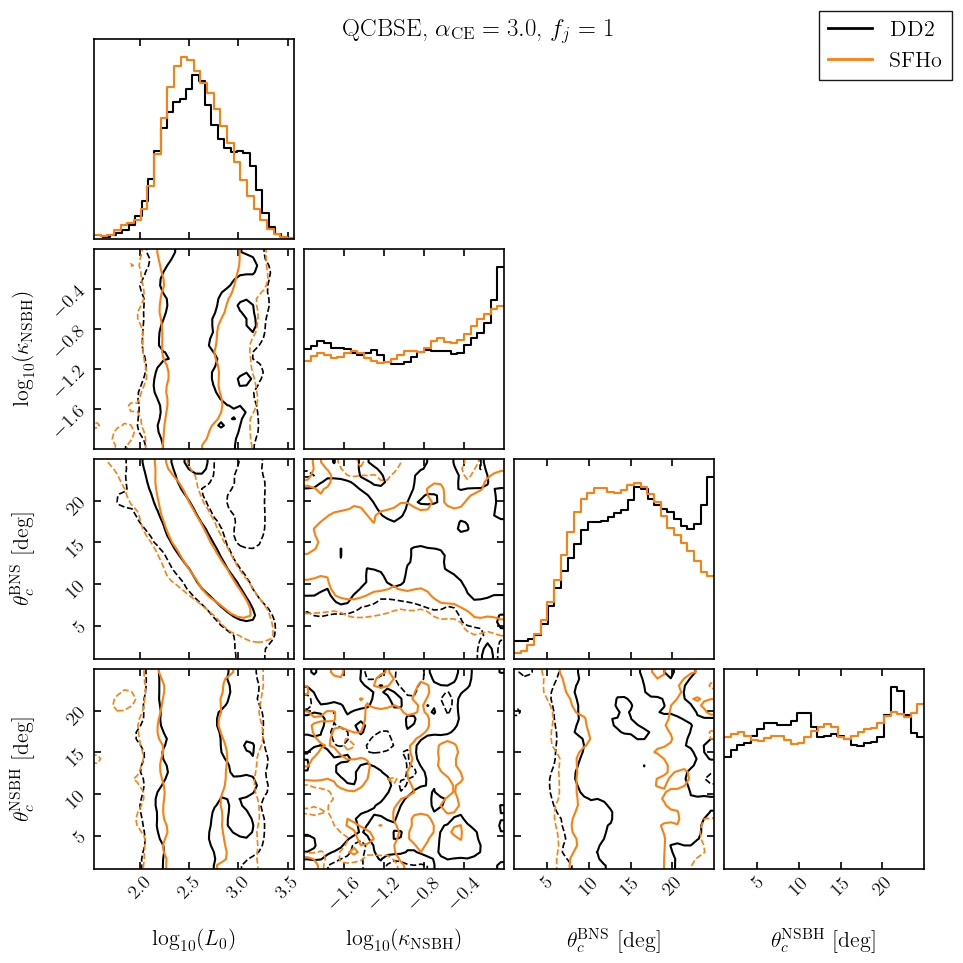

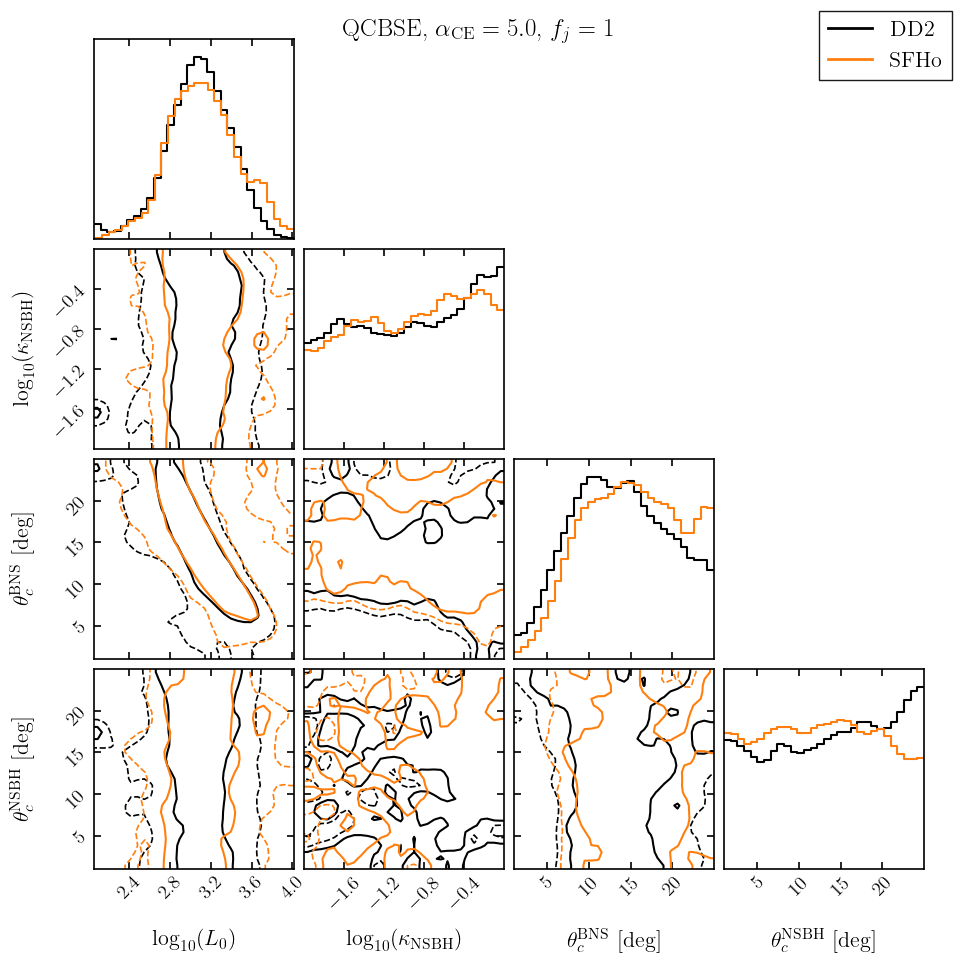

In [11]:
#for nsbh_series in NSBH_SERIES:
for fj_bns in FJ_LIST:
    figures = plot_corner(
        alphas=POSSIBLE_ALPHA,
        fj_bns=fj_bns,
        geom_eff_func=GEOM_EFF_FUNC,
        population=POPULATION,
        nsbh_series=NSBH_SERIES,
        burn_frac=0.33,
        thin=10,
    )

    for alpha, fig in figures.items():
        output_name = (
            f"full_corner_{POPULATION}_"
            f"{alpha}_fj_{fj_bns:g}_{GEOM_LABEL_CURRENT}.pdf"
        )

        fig.savefig(
            IMAGES_FOLDER / output_name,
            bbox_inches="tight",
        )
        plt.show()

In [90]:
print("Corner plots saved to:", IMAGES_FOLDER)
print("With names")

for fj_bns in FJ_LIST:
    for alpha in POSSIBLE_ALPHA:
        output_name = (
            f"full_corner_{POPULATION}_{alpha}_fj_{fj_bns:g}_{GEOM_LABEL_CURRENT}.pdf"
        )
        print(output_name)

Corner plots saved to: Images
With names
full_corner_qcbse_A3.0_fj_0.1_fixed.pdf
full_corner_qcbse_A5.0_fj_0.1_fixed.pdf
full_corner_qcbse_A3.0_fj_0.5_fixed.pdf
full_corner_qcbse_A5.0_fj_0.5_fixed.pdf
full_corner_qcbse_A3.0_fj_1_fixed.pdf
full_corner_qcbse_A5.0_fj_1_fixed.pdf


## Posterior rate-fraction grid

The runner saves predicted BNS and NSBH counts as blobs at every accepted sample. This cell converts them to yearly rates and plots $\eta_{\rm BNS}$ against $\eta_{\rm NSBH}$ for every fixed $f_j$ and $\alpha_{\rm CE}$.

In [91]:
rate_posteriors = collect_rate_posteriors(
    alphas=POSSIBLE_ALPHA,
    fj_list=FJ_LIST,
    population=POPULATION,
    nsbh_series=NSBH_SERIES,
    geom_eff_func=GEOM_EFF_FUNC,
    datafiles=DATAFILES,
    burn_frac=0.33,
    thin=10,
)

Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
BNS: R(z=0.01)=34.05 Gpc^-3 yr^-1; all-sky rate=2.616e+04 yr^-1; MC sample=1
NSBH_DD2_uniform_chi_0_1: R(z=0.01)=5.06 Gpc^-3 yr^-1; all-sky rate=7.750e+03 yr^-1; MC sample=1
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.1_geometric-efficiency-fixed_qcbse-NSBH-DD2-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.1_geometric-efficiency-fixed_qcbse-NSBH-SFHo-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.5_geometric-efficiency-fixed_qcbse-NSBH-DD2-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.5_geometric-efficiency-fixed_qcbse-NSBH-SFHo-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_1_geometric-efficiency-fixed_qcb

1D fraction plot saved to: Images/qcbse_full_likelihood_fraction_1d_fixed.pdf


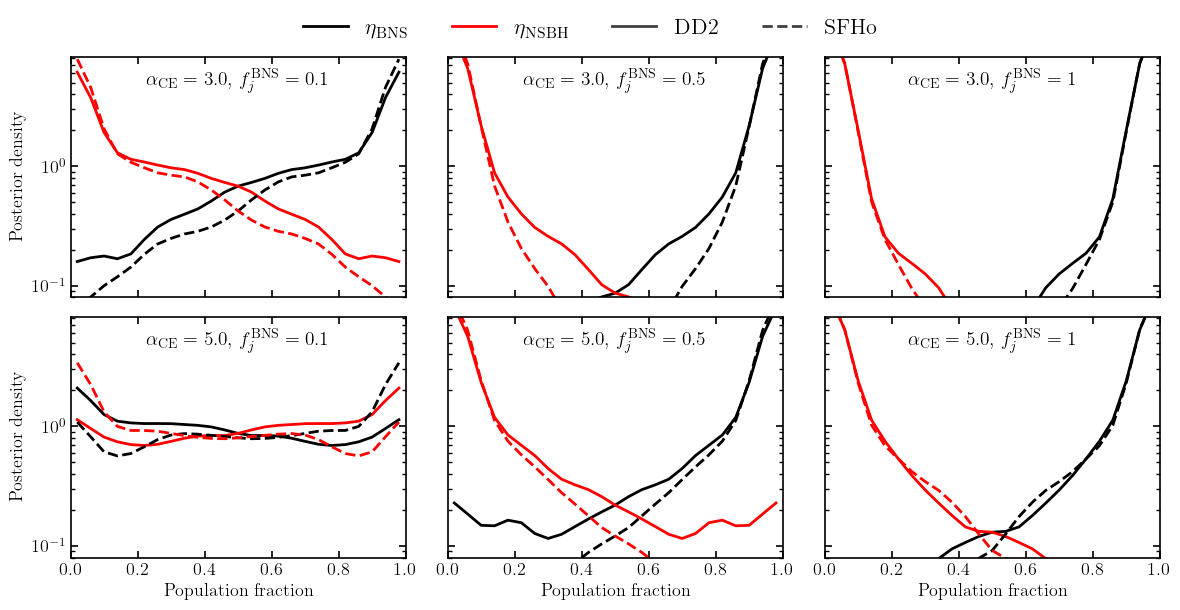

In [93]:
from mcmc_runny import plot_fraction_1d

fj_list = [0.1, 0.5, 1.0]
fig_1d, axes_1d = plot_fraction_1d(
    rate_posteriors,
    fj_list=fj_list,
    alpha_list=POSSIBLE_ALPHA,
    nsbh_populations=NSBH_SERIES,
    population_labels=["DD2", "SFHo"],
    bins=25,
    smooth_sigma=1,
)

#save
fig_1d.savefig(
    IMAGES_FOLDER / f"{POPULATION}_full_likelihood_fraction_1d_{GEOM_LABEL_CURRENT}.pdf",
    bbox_inches="tight",
)

# geometry 
print("1D fraction plot saved to:", IMAGES_FOLDER / f"{POPULATION}_full_likelihood_fraction_1d_{GEOM_LABEL_CURRENT}.pdf")

plt.show()

In [94]:
from mcmc_runny import summarize_fraction_posteriors, format_fraction_summary_table

fraction_summary = summarize_fraction_posteriors(
    rate_posteriors,
    fj_list=FJ_LIST,
    alpha_list=POSSIBLE_ALPHA,
    nsbh_populations=NSBH_SERIES,
    population_labels=["DD2", "SFHo"],
    credible_level=0.90,
)

fraction_table = format_fraction_summary_table(
    fraction_summary,
    decimals=3,
)

display(fraction_table)

,alpha,fj_bns,EOS,"eta_NSBH (median, 90% CI)","eta_BNS (median, 90% CI)"
0,3.0,0.1,DD2,0.139 (+0.598/-0.138),0.861 (+0.138/-0.598)
1,3.0,0.1,SFHo,0.064 (+0.600/-0.064),0.936 (+0.064/-0.600)
2,3.0,0.5,DD2,0.006 (+0.342/-0.006),0.994 (+0.006/-0.342)
3,3.0,0.5,SFHo,0.003 (+0.126/-0.003),0.997 (+0.003/-0.126)
4,3.0,1.0,DD2,0.002 (+0.129/-0.002),0.998 (+0.002/-0.129)
5,3.0,1.0,SFHo,0.002 (+0.105/-0.002),0.998 (+0.002/-0.105)
6,5.0,0.1,DD2,0.597 (+0.389/-0.559),0.403 (+0.559/-0.389)
7,5.0,0.1,SFHo,0.362 (+0.601/-0.357),0.638 (+0.357/-0.601)
8,5.0,0.5,DD2,0.026 (+0.659/-0.026),0.974 (+0.026/-0.659)
9,5.0,0.5,SFHo,0.015 (+0.348/-0.015),0.985 (+0.015/-0.348)
